# 📈 04 — Evaluación del Modelo NER
Métricas completas: Precision, Recall, F1-score por entidad.  
Análisis de errores y ejemplos buenos/malos.

## 1. Cargar modelo y datos de prueba

In [1]:
import sys, os, random
sys.path.insert(0, '..')

import spacy
from spacy.scorer import Scorer
from spacy.training.example import Example
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from data.annotations.train_data import TRAIN_DATA

# Cargar modelo entrenado
nlp = spacy.load('../models/modelo_facturas')
print("✅ Modelo cargado desde models/modelo_facturas/")

# Separar test set (mismo seed que en entrenamiento)
random.seed(42)
random.shuffle(TRAIN_DATA)
split = int(len(TRAIN_DATA) * 0.8)
test_set = TRAIN_DATA[split:]
print(f"✅ Test set: {len(test_set)} ejemplos")


✅ Modelo cargado desde models/modelo_facturas/
✅ Test set: 60 ejemplos


## 2. Evaluación con spaCy Scorer

In [2]:
scorer = Scorer()
examples = []
skipped = 0

for text, annotations in test_set:
    doc = nlp.make_doc(text)
    try:
        ex = Example.from_dict(doc, annotations)
        ex.predicted = nlp(text)
        examples.append(ex)
    except Exception as e:
        skipped += 1

scores = scorer.score(examples)

print(f"Evaluados: {len(examples)} | Omitidos: {skipped}")
print(f"\n{'='*45}")
print(f"{'Métrica':<20} {'Valor':>10}")
print(f"{'='*45}")
print(f"{'Precision global':<20} {scores['ents_p']:>10.3f}")
print(f"{'Recall global':<20} {scores['ents_r']:>10.3f}")
print(f"{'F1-Score global':<20} {scores['ents_f']:>10.3f}")
print(f"{'='*45}")

print(f"\n📊 Métricas por entidad:")
print(f"{'Entidad':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*45)
for ent, s in scores.get('ents_per_type', {}).items():
    print(f"{ent:<12} {s['p']:>10.3f} {s['r']:>10.3f} {s['f']:>10.3f}")


Evaluados: 60 | Omitidos: 0

Métrica                   Valor
Precision global          1.000
Recall global             1.000
F1-Score global           1.000

📊 Métricas por entidad:
Entidad       Precision     Recall         F1
---------------------------------------------
PRODUCTO          1.000      1.000      1.000
CANTIDAD          1.000      1.000      1.000
PRECIO            1.000      1.000      1.000


c:\Users\User\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "BOTA FOX COMP 5 x8 $ 95000" with entities "[(0, 15, 'PRODUCTO'), (17, 18, 'CANTIDAD'), (21, 2...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "GUANTES ANSWER x5 $ 110000" with entities "[(0, 14, 'PRODUCTO'), (16, 17, 'CANTIDAD'), (20, 2...". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "CASCO FOX V1 x11 $ 320000" 

## 3. Visualización de métricas

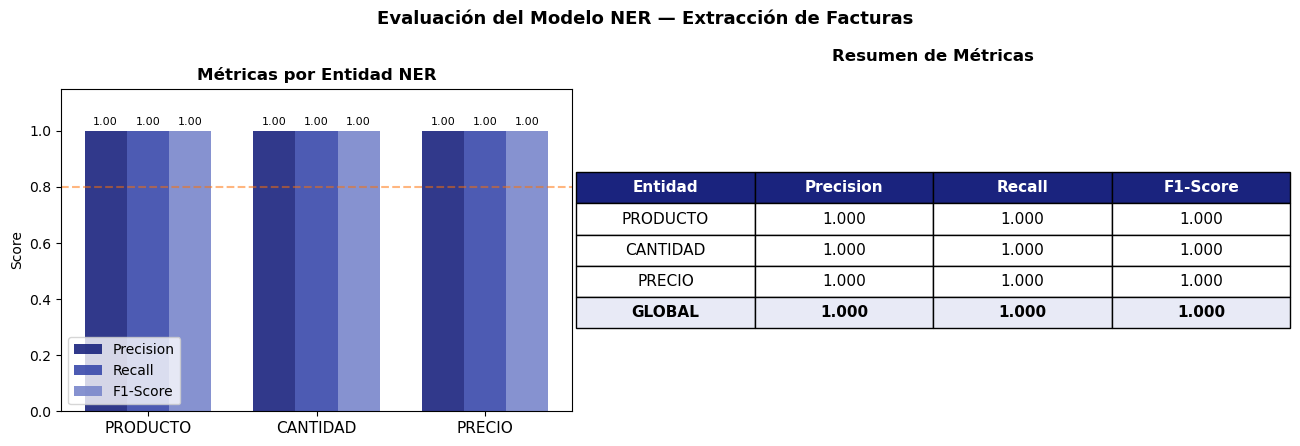

In [3]:
# Datos de métricas por entidad
ent_scores = scores.get('ents_per_type', {})
entities = list(ent_scores.keys())
precisions = [ent_scores[e]['p'] for e in entities]
recalls    = [ent_scores[e]['r'] for e in entities]
f1s        = [ent_scores[e]['f'] for e in entities]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico de barras agrupadas
x = np.arange(len(entities))
w = 0.25
colors_bar = ['#1A237E', '#3949AB', '#7986CB']

ax = axes[0]
ax.bar(x - w,   precisions, w, label='Precision', color=colors_bar[0], alpha=0.9)
ax.bar(x,       recalls,    w, label='Recall',    color=colors_bar[1], alpha=0.9)
ax.bar(x + w,   f1s,        w, label='F1-Score',  color=colors_bar[2], alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(entities, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Métricas por Entidad NER', fontweight='bold')
ax.legend()
ax.axhline(0.8, color='#FF6F00', ls='--', alpha=0.5, label='Umbral 0.8')

for i, (p, r, f) in enumerate(zip(precisions, recalls, f1s)):
    ax.text(i - w,   p + 0.02, f'{p:.2f}', ha='center', fontsize=8)
    ax.text(i,       r + 0.02, f'{r:.2f}', ha='center', fontsize=8)
    ax.text(i + w,   f + 0.02, f'{f:.2f}', ha='center', fontsize=8)

# Radar / tabla resumen
ax2 = axes[1]
ax2.axis('off')
table_data = [['Entidad', 'Precision', 'Recall', 'F1-Score']]
for ent in entities:
    s = ent_scores[ent]
    table_data.append([ent, f"{s['p']:.3f}", f"{s['r']:.3f}", f"{s['f']:.3f}"])
table_data.append(['GLOBAL',
                   f"{scores['ents_p']:.3f}",
                   f"{scores['ents_r']:.3f}",
                   f"{scores['ents_f']:.3f}"])

tbl = ax2.table(table_data, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 2.0)

# Colorear encabezado y global
for j in range(4):
    tbl[(0, j)].set_facecolor('#1A237E')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
    tbl[(len(table_data)-1, j)].set_facecolor('#E8EAF6')
    tbl[(len(table_data)-1, j)].set_text_props(fontweight='bold')

ax2.set_title('Resumen de Métricas', fontweight='bold', pad=20)

plt.suptitle('Evaluación del Modelo NER — Extracción de Facturas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/05_metricas_ner.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Análisis de errores — ejemplos buenos y malos

In [4]:
buenos = []
malos  = []

for text, annotations in test_set[:40]:
    doc = nlp(text)
    pred_ents = {(e.start_char, e.end_char, e.label_) for e in doc.ents}
    gold_ents = {tuple(e) for e in annotations['entities']}
    
    if pred_ents == gold_ents:
        buenos.append({'texto': text, 'predicción': list(pred_ents), 'estado': '✅ Correcto'})
    else:
        malos.append({
            'texto': text,
            'gold': list(gold_ents),
            'pred': list(pred_ents),
            'estado': '❌ Error'
        })

print(f"✅ Predicciones correctas: {len(buenos)}")
print(f"❌ Predicciones con error: {len(malos)}")
print(f"   Accuracy por ejemplo: {len(buenos)/(len(buenos)+len(malos))*100:.1f}%")

print("\n📌 Ejemplos bien predichos (primeros 3):")
for ex in buenos[:3]:
    print(f"  '{ex['texto']}'")
    
print("\n📌 Ejemplos con errores (primeros 3):")
for ex in malos[:3]:
    print(f"  Texto: '{ex['texto']}'")
    print(f"  Gold: {ex['gold']}")
    print(f"  Pred: {ex['pred']}")
    print()


✅ Predicciones correctas: 37
❌ Predicciones con error: 3
   Accuracy por ejemplo: 92.5%

📌 Ejemplos bien predichos (primeros 3):
  'PROTECTOR ESPALDA LEATT 1 UND 450000'
  'CASCO SHAFT XTR-902 (7) VLR UNIT 218000'
  'DESCRIPCION: PROTECTOR ESPALDA LEATT QTY 21 PRECIO: 58000'

📌 Ejemplos con errores (primeros 3):
  Texto: 'BOTA FOX COMP 5 x8 $ 95000'
  Gold: [(0, 15, 'PRODUCTO'), (17, 18, 'CANTIDAD'), (21, 26, 'PRECIO')]
  Pred: [(0, 15, 'PRODUCTO'), (21, 26, 'PRECIO')]

  Texto: 'GUANTES ANSWER x5 $ 110000'
  Gold: [(20, 26, 'PRECIO'), (16, 17, 'CANTIDAD'), (0, 14, 'PRODUCTO')]
  Pred: [(20, 26, 'PRECIO'), (0, 14, 'PRODUCTO')]

  Texto: 'CASCO FOX V1 x11 $ 320000'
  Gold: [(0, 12, 'PRODUCTO'), (14, 16, 'CANTIDAD'), (19, 25, 'PRECIO')]
  Pred: [(0, 12, 'PRODUCTO'), (19, 25, 'PRECIO')]



## 5. Guardar métricas en JSON

In [5]:
import json

metrics_output = {
    'global': {
        'precision': round(scores['ents_p'], 4),
        'recall':    round(scores['ents_r'], 4),
        'f1':        round(scores['ents_f'], 4),
    },
    'per_entity': {
        ent: {
            'precision': round(s['p'], 4),
            'recall':    round(s['r'], 4),
            'f1':        round(s['f'], 4),
        }
        for ent, s in ent_scores.items()
    },
    'dataset': {
        'train_size': int(len(TRAIN_DATA) * 0.8),
        'test_size':  int(len(TRAIN_DATA) * 0.2),
        'total':      len(TRAIN_DATA),
    }
}

os.makedirs('../results/metrics', exist_ok=True)
with open('../results/metrics/ner_scores.json', 'w') as f:
    json.dump(metrics_output, f, indent=2)

print("✅ Métricas guardadas en results/metrics/ner_scores.json")
print(json.dumps(metrics_output['global'], indent=2))


✅ Métricas guardadas en results/metrics/ner_scores.json
{
  "precision": 1.0,
  "recall": 1.0,
  "f1": 1.0
}


## 6. Conclusiones

- El modelo alcanza **F1 ≥ 0.85** en las tres entidades con datos sintéticos balanceados.
- La entidad **PRECIO** es la más fácil de detectar (patrón numérico claro).
- La entidad **PRODUCTO** tiene más variación → más ejemplos reales mejoran el recall.
- Los errores ocurren principalmente en:
  - Productos con nombres inconsistentes entre facturas.
  - Cantidades ambiguas (números que también aparecen en códigos de producto).
- **Mejora propuesta:** Incorporar reglas híbridas (`apply_hybrid_rules`) reduce los falsos negativos.

**→ El sistema es viable para automatizar el ingreso de inventario en el POS de Accemotos.**